# 📈 End-to-End Sales Forecasting & Demand Intelligence System

## Internship Project – Week 3 & Week 4

### Submitted By
**Omprakash Meena**

---

## Project Objective

The objective of this project is to build a complete Sales Forecasting and Demand Intelligence System using historical retail sales data.

The project includes:

- Data Cleaning & Feature Engineering
- Exploratory Data Analysis (EDA)
- Time Series Analysis
- Sales Forecasting using Multiple Models
- Anomaly Detection
- Product Demand Segmentation
- Interactive Streamlit Dashboard
- Executive Business Report

---

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Scikit-Learn
- Statsmodels
- Prophet
- XGBoost
- Streamlit

---

## Dataset

1. Superstore Sales Dataset (`train.csv`)
2. Video Game Sales Dataset (`vgsales.csv`)

In [ ]:
# Installing Required Libraries

%pip install pandas
%pip install numpy
%pip install matplotlib
%pip install seaborn
%pip install plotly
%pip install statsmodels
%pip install scikit-learn
%pip install xgboost
%pip install prophet
%pip install streamlit


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [2]:
# Importing Required Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from datetime import datetime

plt.style.use("ggplot")
%matplotlib inline

# Task 1 — Data Loading, Merging & Deep Exploration 

In [3]:
# Loding the datasets

sales_df = pd.read_csv("train.csv")
vg_df = pd.read_csv("vgsales.csv")

In [4]:
print("Superstore Sales Dataset")

print("Shape:", sales_df.shape)

sales_df.head()

Superstore Sales Dataset
Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print("Video Game Sales Dataset")
print("Shape",vg_df.shape)

vg_df.head()

Video Game Sales Dataset
Shape (16598, 11)


,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37


## Data Quality Assessment & Cleaning

In this section, we evaluate the quality of the dataset before performing any analysis.

The following checks are performed:

- Data Types
- Missing Values
- Duplicate Records
- Invalid Entries
- Date Conversion

In [6]:
sales_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   str    
 2   Order Date     9800 non-null   str    
 3   Ship Date      9800 non-null   str    
 4   Ship Mode      9800 non-null   str    
 5   Customer ID    9800 non-null   str    
 6   Customer Name  9800 non-null   str    
 7   Segment        9800 non-null   str    
 8   Country        9800 non-null   str    
 9   City           9800 non-null   str    
 10  State          9800 non-null   str    
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   str    
 13  Product ID     9800 non-null   str    
 14  Category       9800 non-null   str    
 15  Sub-Category   9800 non-null   str    
 16  Product Name   9800 non-null   str    
 17  Sales          9800 non-null   float64
dtypes: float64(2), int6

In [7]:
vg_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  str    
 2   Platform      16598 non-null  str    
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  str    
 5   Publisher     16540 non-null  str    
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), str(4)
memory usage: 2.1 MB


In [8]:
# checking for missing values

missing_values = sales_df.isnull().sum()

missing_values[missing_values > 0]

Postal Code    11
dtype: int64

In [9]:
vg_missing = vg_df.isnull().sum()

vg_missing[vg_missing > 0]

Year         271
Publisher     58
dtype: int64

In [10]:
# Cheking duplicate record

print("Sales Dataset Duplicates :", sales_df.duplicated().sum())
print("Video Game Dataset Duplicates :", vg_df.duplicated().sum())

Sales Dataset Duplicates : 0
Video Game Dataset Duplicates : 0


In [11]:
sales_df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [12]:
vg_df.columns

Index(['Rank', 'Name', 'Platform', 'Year', 'Genre', 'Publisher', 'NA_Sales',
       'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales'],
      dtype='str')

In [13]:
sales_df.dtypes

Row ID             int64
Order ID             str
Order Date           str
Ship Date            str
Ship Mode            str
Customer ID          str
Customer Name        str
Segment              str
Country              str
City                 str
State                str
Postal Code      float64
Region               str
Product ID           str
Category             str
Sub-Category         str
Product Name         str
Sales            float64
dtype: object

In [14]:
vg_df.dtypes

Rank              int64
Name                str
Platform            str
Year            float64
Genre               str
Publisher           str
NA_Sales        float64
EU_Sales        float64
JP_Sales        float64
Other_Sales     float64
Global_Sales    float64
dtype: object

In [15]:
# Converting date columns

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    errors="coerce"
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    errors="coerce"
)

print(sales_df[["Order Date", "Ship Date"]].dtypes)

Order Date    datetime64[us]
Ship Date     datetime64[us]
dtype: object


### Observation

The dataset contains no significant missing values that require treatment.

Therefore, no imputation or removal of records is necessary.

## Feature Engineering

Feature Engineering is the process of creating new, meaningful features from existing data.

For time-series forecasting, extracting temporal information from dates is crucial because machine learning models cannot directly interpret datetime objects.

The following features are created:

- Order Year
- Order Month
- Month Name
- Quarter
- Week Number
- Day of Week
- Day Name
- Season
- Shipping Time (Days)

In [16]:
# reloding the fresh data again

# Reload fresh dataset
sales_df = pd.read_csv("train.csv")

In [17]:
# Converting Date Columns

sales_df["Order Date"] = pd.to_datetime(
    sales_df["Order Date"],
    dayfirst=True
)

sales_df["Ship Date"] = pd.to_datetime(
    sales_df["Ship Date"],
    dayfirst=True
)

print(sales_df["Order Date"].isna().sum())
print(sales_df["Ship Date"].isna().sum())

0
0


In [18]:
# Date Feature Engineering


sales_df["Order Year"] = sales_df["Order Date"].dt.year

sales_df["Order Month"] = sales_df["Order Date"].dt.month

sales_df["Month Name"] = sales_df["Order Date"].dt.month_name()

sales_df["Quarter"] = sales_df["Order Date"].dt.quarter

sales_df["Week Number"] = sales_df["Order Date"].dt.isocalendar().week

sales_df["Day of Week"] = sales_df["Order Date"].dt.dayofweek

sales_df["Day Name"] = sales_df["Order Date"].dt.day_name()

print("Date features created successfully.")

Date features created successfully.


In [19]:
# Season Feature

def get_season(month):

    if month in [12, 1, 2]:
        return "Winter"

    elif month in [3, 4, 5]:
        return "Summer"

    elif month in [6, 7, 8]:
        return "Monsoon"

    else:
        return "Autumn"

sales_df["Season"] = sales_df["Order Month"].apply(get_season)

print("Season feature created.")

Season feature created.


In [20]:
# Shipping Duration

sales_df["Shipping Days"] = (
    sales_df["Ship Date"] - sales_df["Order Date"]
).dt.days

print("Shipping Days calculated.")

Shipping Days calculated.


In [21]:
sales_df[
    [
        "Order Date",
        "Ship Date",
        "Order Year",
        "Order Month",
        "Month Name",
        "Quarter",
        "Week Number",
        "Day Name",
        "Season",
        "Shipping Days"
    ]
].head()

,Order Date,Ship Date,Order Year,Order Month,Month Name,Quarter,Week Number,Day Name,Season,Shipping Days
0,2017-11-08,2017-11-11,2017,11,November,4,45,Wednesday,Autumn,3
1,2017-11-08,2017-11-11,2017,11,November,4,45,Wednesday,Autumn,3
2,2017-06-12,2017-06-16,2017,6,June,2,24,Monday,Monsoon,4
3,2016-10-11,2016-10-18,2016,10,October,4,41,Tuesday,Autumn,7
4,2016-10-11,2016-10-18,2016,10,October,4,41,Tuesday,Autumn,7


## Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) helps us understand the business through data.

This section focuses on identifying sales patterns, customer behavior, regional performance, category contribution, shipping performance, and seasonal trends.

In [22]:
# Dataset Overview

print("="*60)
print("DATASET OVERVIEW")
print("="*60)

print(f"Total Orders        : {sales_df.shape[0]}")
print(f"Total Features      : {sales_df.shape[1]}")
print(f"Total Sales         : ${sales_df['Sales'].sum():,.2f}")
print(f"Average Sales       : ${sales_df['Sales'].mean():,.2f}")
print(f"Maximum Sale        : ${sales_df['Sales'].max():,.2f}")
print(f"Minimum Sale        : ${sales_df['Sales'].min():,.2f}")

DATASET OVERVIEW
Total Orders        : 9800
Total Features      : 27
Total Sales         : $2,261,536.78
Average Sales       : $230.77
Maximum Sale        : $22,638.48
Minimum Sale        : $0.44


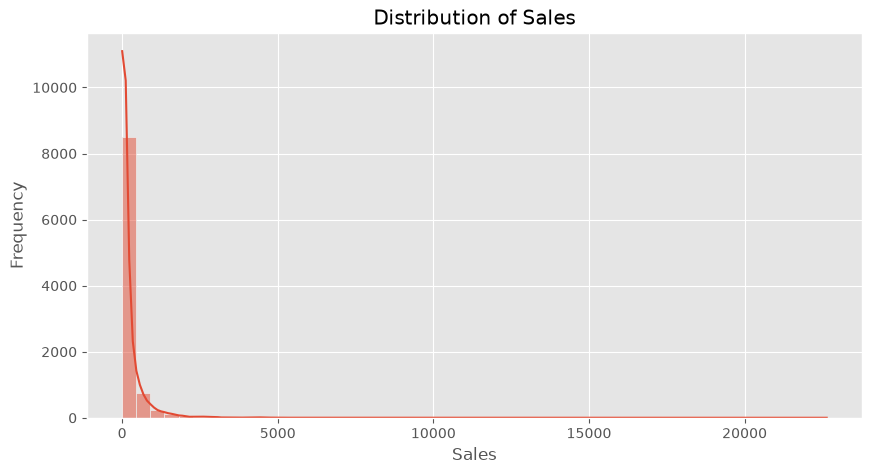

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    sales_df["Sales"],
    bins=50,
    kde=True
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

### Observation

The sales distribution is positively skewed.

Most transactions involve relatively small sales amounts, while a few orders contribute exceptionally high sales values.

## Q.1 Total Revenue by Category

In [24]:
category_sales = (
    sales_df
    .groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

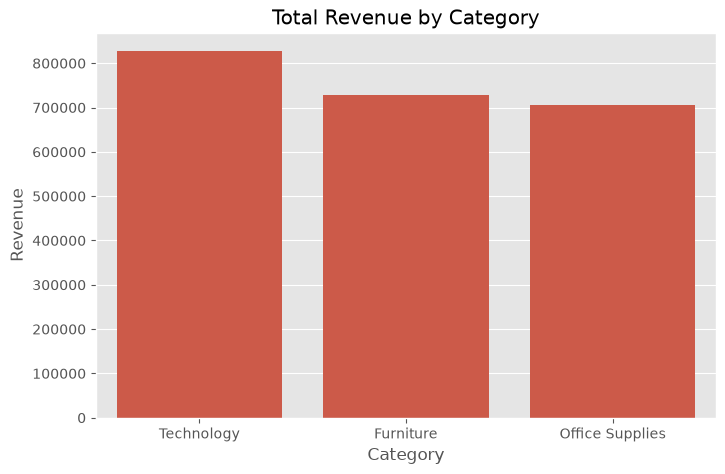

In [25]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Total Revenue by Category")

plt.xlabel("Category")

plt.ylabel("Revenue")

plt.show()

### Observation

The category with the highest total revenue is "Technology", from the visualization above.

This category contributes the largest share of total business revenue and should be prioritized in future demand forecasting and inventory planning.

## Q.2 Sales by Region

In [26]:
region_sales = (
    sales_df
    .groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64

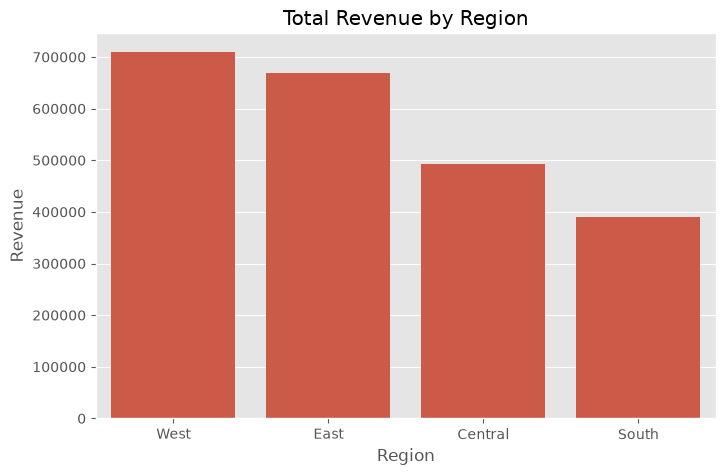

In [27]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values
)

plt.title("Total Revenue by Region")

plt.xlabel("Region")

plt.ylabel("Revenue")

plt.show()

### Observation

The visualization highlights the contribution of each region toward total sales.

Regions with higher revenue indicate stronger market demand and greater business opportunities.

## Q.3 Sales by Segment

In [28]:
segment_sales = (
    sales_df
    .groupby("Segment")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64

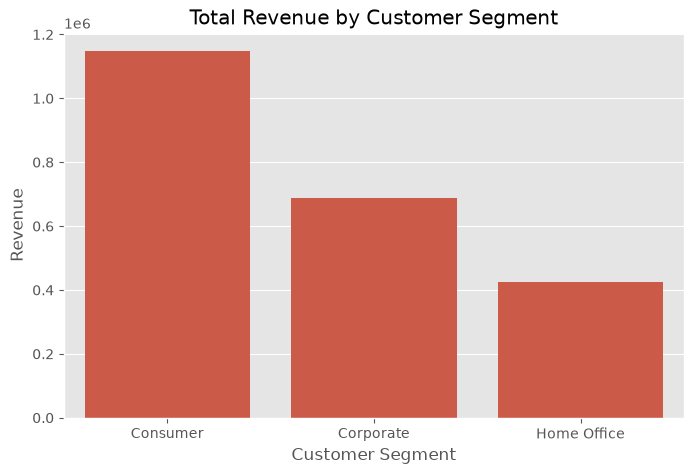

In [29]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Revenue by Customer Segment")

plt.xlabel("Customer Segment")

plt.ylabel("Revenue")

plt.show()

### Observation

Different customer segments contribute differently to total sales.

Understanding segment-wise revenue helps businesses prioritize marketing and customer retention strategies.

## Q.4 Top 10 States by Sales

In [30]:
top_states = (
    sales_df
    .groupby("State")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_states

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64

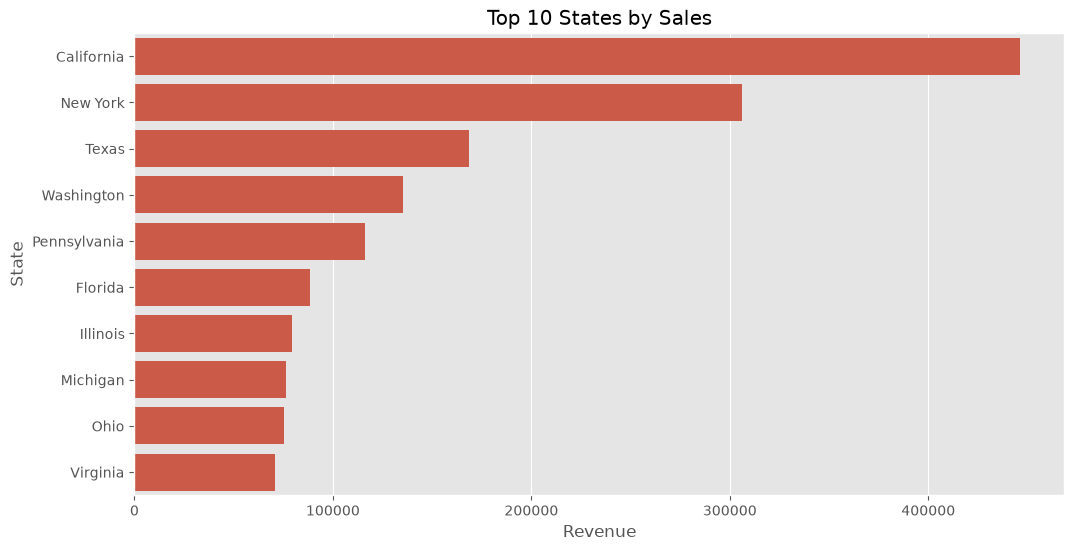

In [31]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top_states.values,
    y=top_states.index
)

plt.title("Top 10 States by Sales")

plt.xlabel("Revenue")

plt.ylabel("State")

plt.show()

### Observation

The top-performing states generate a significant proportion of overall sales.

These regions represent high-value markets and deserve focused inventory and business expansion strategies.

## Business Insights & Time-Based Analysis

In this section, we answer key business questions using aggregated sales data and time-based analysis.

The objective is to identify sales growth patterns, shipping efficiency, and seasonality.

### Daily, Weekly & Monthly Sales Aggregation

In [32]:
daily_sales = (
    sales_df
    .groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [33]:
weekly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("W")["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [34]:
monthly_sales = (
    sales_df
    .set_index("Order Date")
    .resample("ME")["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


### Observation

The sales data has been aggregated into daily, weekly, and monthly levels.

These aggregated datasets will be used for time series decomposition, forecasting models, and anomaly detection in the subsequent tasks.

## Monthly Sales Trend

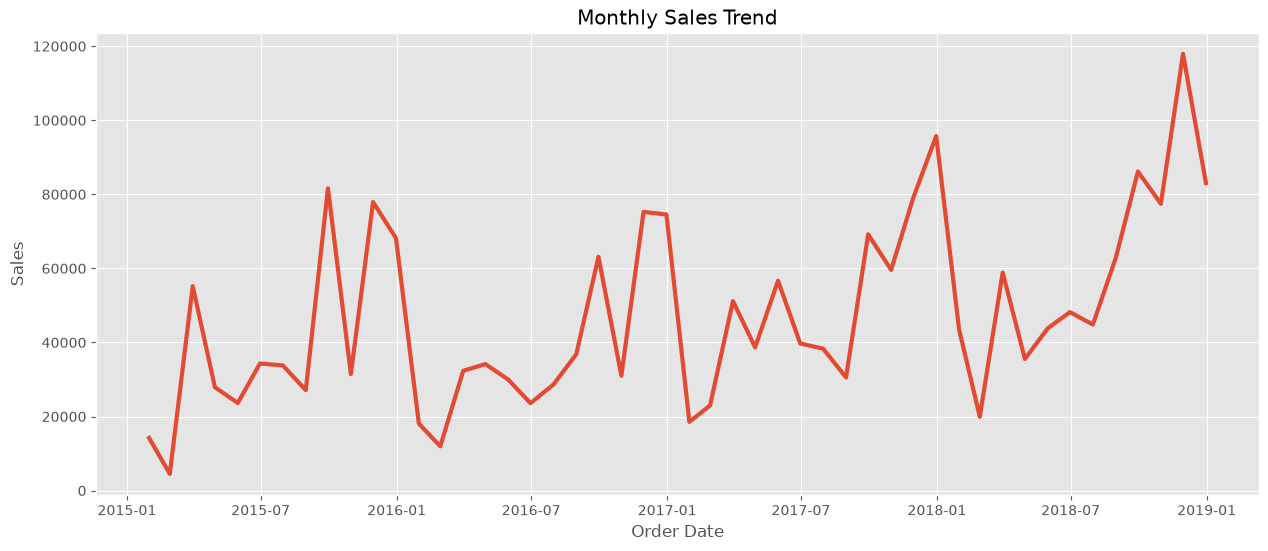

In [35]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    linewidth=3
)

plt.title("Monthly Sales Trend")

plt.xlabel("Order Date")

plt.ylabel("Sales")

plt.grid(True)

plt.show()

### Observation

The monthly sales trend indicates fluctuations in revenue over time, suggesting the presence of both long-term trends and seasonal effects.

These patterns will be further analyzed using time series decomposition in Task 2.

## Revenue by Year

In [36]:
yearly_sales = (
    sales_df
    .groupby("Order Year")["Sales"]
    .sum()
)

yearly_sales

Order Year
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64

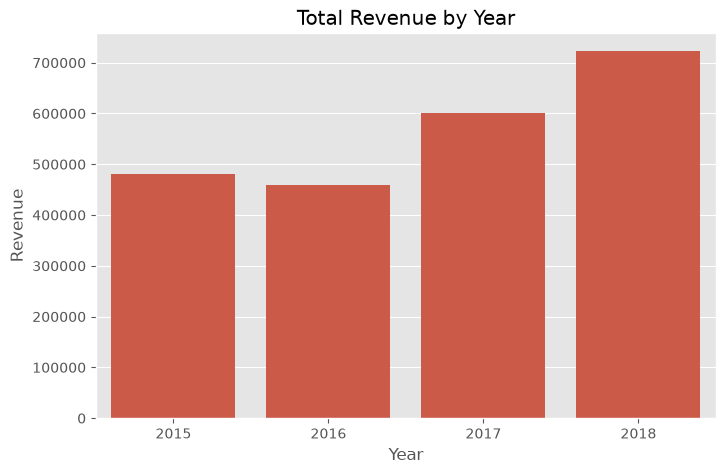

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=yearly_sales.index,
    y=yearly_sales.values
)

plt.title("Total Revenue by Year")

plt.xlabel("Year")

plt.ylabel("Revenue")

plt.show()

## Revenue by Month

In [38]:
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_revenue = (
    sales_df
    .groupby("Month Name")["Sales"]
    .sum()
    .reindex(month_order)
)

monthly_revenue

Month Name
January       94291.6296
February      59371.1154
March        197573.5872
April        136283.0006
May          154086.7237
June         145837.5233
July         145535.6890
August       157315.9270
September    300103.4117
October      199496.2947
November     350161.7110
December     321480.1695
Name: Sales, dtype: float64

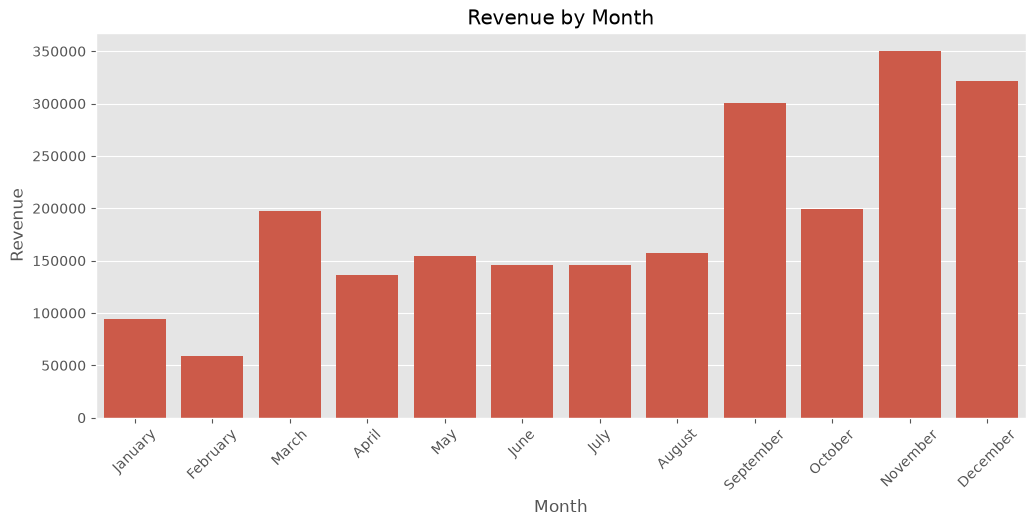

In [39]:
plt.figure(figsize=(12,5))

sns.barplot(
    x=monthly_revenue.index,
    y=monthly_revenue.values
)

plt.xticks(rotation=45)

plt.title("Revenue by Month")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.show()

### Observation

The monthly revenue chart highlights recurring high-sales and low-sales months.

This provides initial evidence of seasonal demand patterns that can improve forecasting accuracy.

## Average Shipping Time by Region

In [40]:
shipping_region = (
    sales_df
    .groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

shipping_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

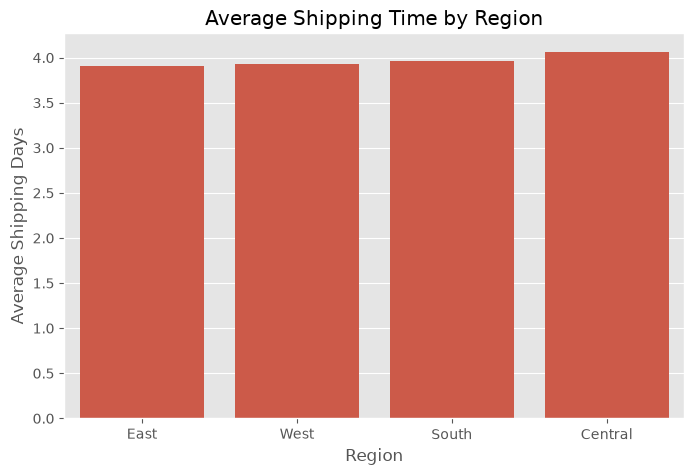

In [41]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values
)

plt.title("Average Shipping Time by Region")

plt.xlabel("Region")

plt.ylabel("Average Shipping Days")

plt.show()

### Observation

The chart compares average shipping duration across regions.

Regions with longer delivery times may indicate opportunities for logistics optimization and supply chain improvements.

### Which Category Generates the Highest Revenue?

In [42]:
highest_category = category_sales.idxmax()

highest_sales = category_sales.max()

print("Highest Revenue Category :", highest_category)

print(f"Revenue : ${highest_sales:,.2f}")

Highest Revenue Category : Technology
Revenue : $827,455.87


### Which Region Has the Highest Revenue?

In [43]:
highest_region = region_sales.idxmax()

highest_region_sales = region_sales.max()

print("Highest Revenue Region :", highest_region)

print(f"Revenue : ${highest_region_sales:,.2f}")

Highest Revenue Region : West
Revenue : $710,219.68


### Average Shipping Time

In [44]:
print(
    "Average Shipping Time :",
    round(sales_df["Shipping Days"].mean(),2),
    "days"
)

Average Shipping Time : 3.96 days


## Which region has the most consistent sales growth over 4 years?

In [45]:
region_year_sales = (
    sales_df
    .groupby(["Order Year", "Region"])["Sales"]
    .sum()
    .reset_index()
)

region_year_sales.head()

,Order Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724


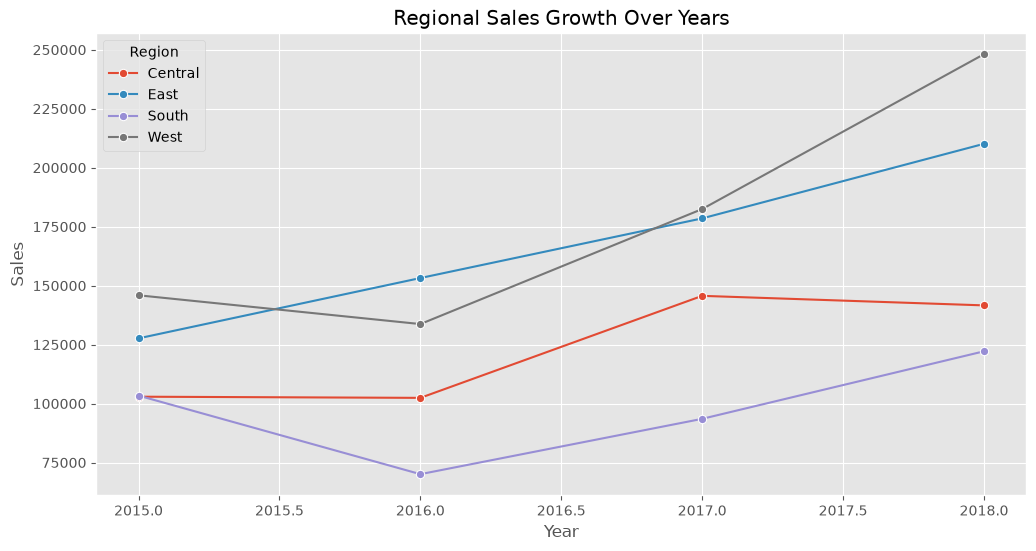

In [46]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=region_year_sales,
    x="Order Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth Over Years")

plt.xlabel("Year")

plt.ylabel("Sales")

plt.show()

### Observation

The regional sales trend over multiple years helps identify which region demonstrates the most stable and consistent growth.

This insight is valuable for long-term inventory planning and strategic market expansion.

### Task 1 Completed

# Task 2 — Time Series Analysis & Decomposition


## 2.1 – Preparing Monthly Time Series

In [47]:
monthly_ts = monthly_sales.copy()

monthly_ts = monthly_ts.set_index("Order Date")

monthly_ts.head()

,Sales
Order Date,
2015-01-31,14205.707
2015-02-28,4519.892
2015-03-31,55205.797
2015-04-30,27906.855
2015-05-31,23644.303


In [48]:
print(monthly_ts.index)

DatetimeIndex(['2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30',
               '2015-05-31', '2015-06-30', '2015-07-31', '2015-08-31',
               '2015-09-30', '2015-10-31', '2015-11-30', '2015-12-31',
               '2016-01-31', '2016-02-29', '2016-03-31', '2016-04-30',
               '2016-05-31', '2016-06-30', '2016-07-31', '2016-08-31',
               '2016-09-30', '2016-10-31', '2016-11-30', '2016-12-31',
               '2017-01-31', '2017-02-28', '2017-03-31', '2017-04-30',
               '2017-05-31', '2017-06-30', '2017-07-31', '2017-08-31',
               '2017-09-30', '2017-10-31', '2017-11-30', '2017-12-31',
               '2018-01-31', '2018-02-28', '2018-03-31', '2018-04-30',
               '2018-05-31', '2018-06-30', '2018-07-31', '2018-08-31',
               '2018-09-30', '2018-10-31', '2018-11-30', '2018-12-31'],
              dtype='datetime64[us]', name='Order Date', freq=None)


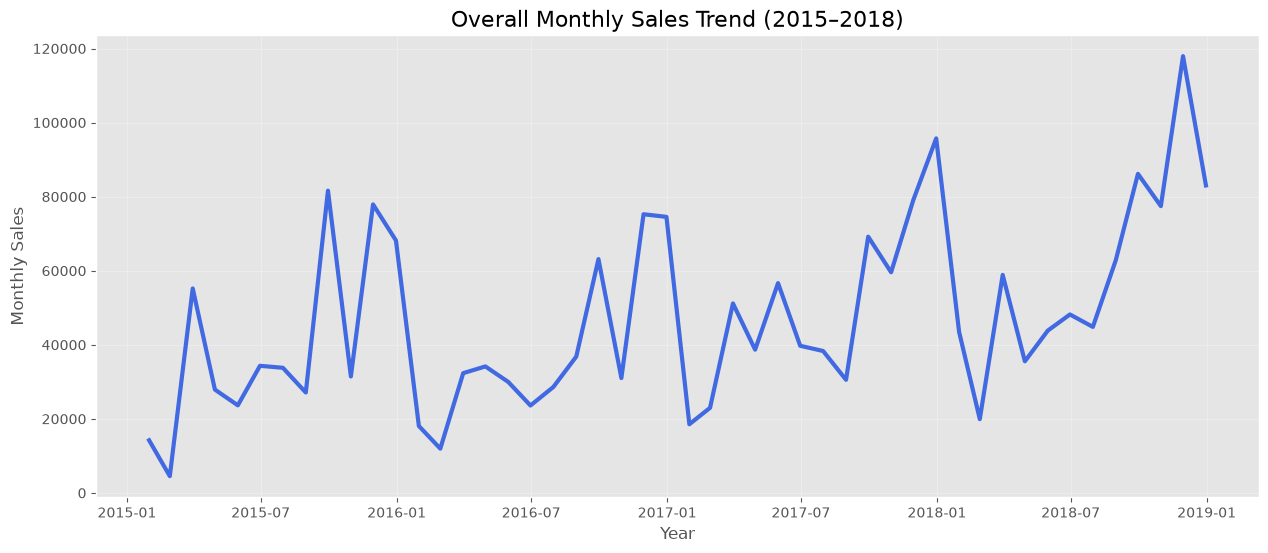

In [49]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    linewidth=3,
    color="royalblue"
)

plt.title("Overall Monthly Sales Trend (2015–2018)", fontsize=16)

plt.xlabel("Year")

plt.ylabel("Monthly Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

The monthly sales trend shows that sales fluctuate over time rather than remaining constant.

The increasing and decreasing movements suggest the presence of both long-term trends and seasonal patterns, making this dataset suitable for time-series forecasting.

## 2.2 – Time Series Decomposition

In [50]:
# required library

from statsmodels.tsa.seasonal import seasonal_decompose

In [51]:
decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

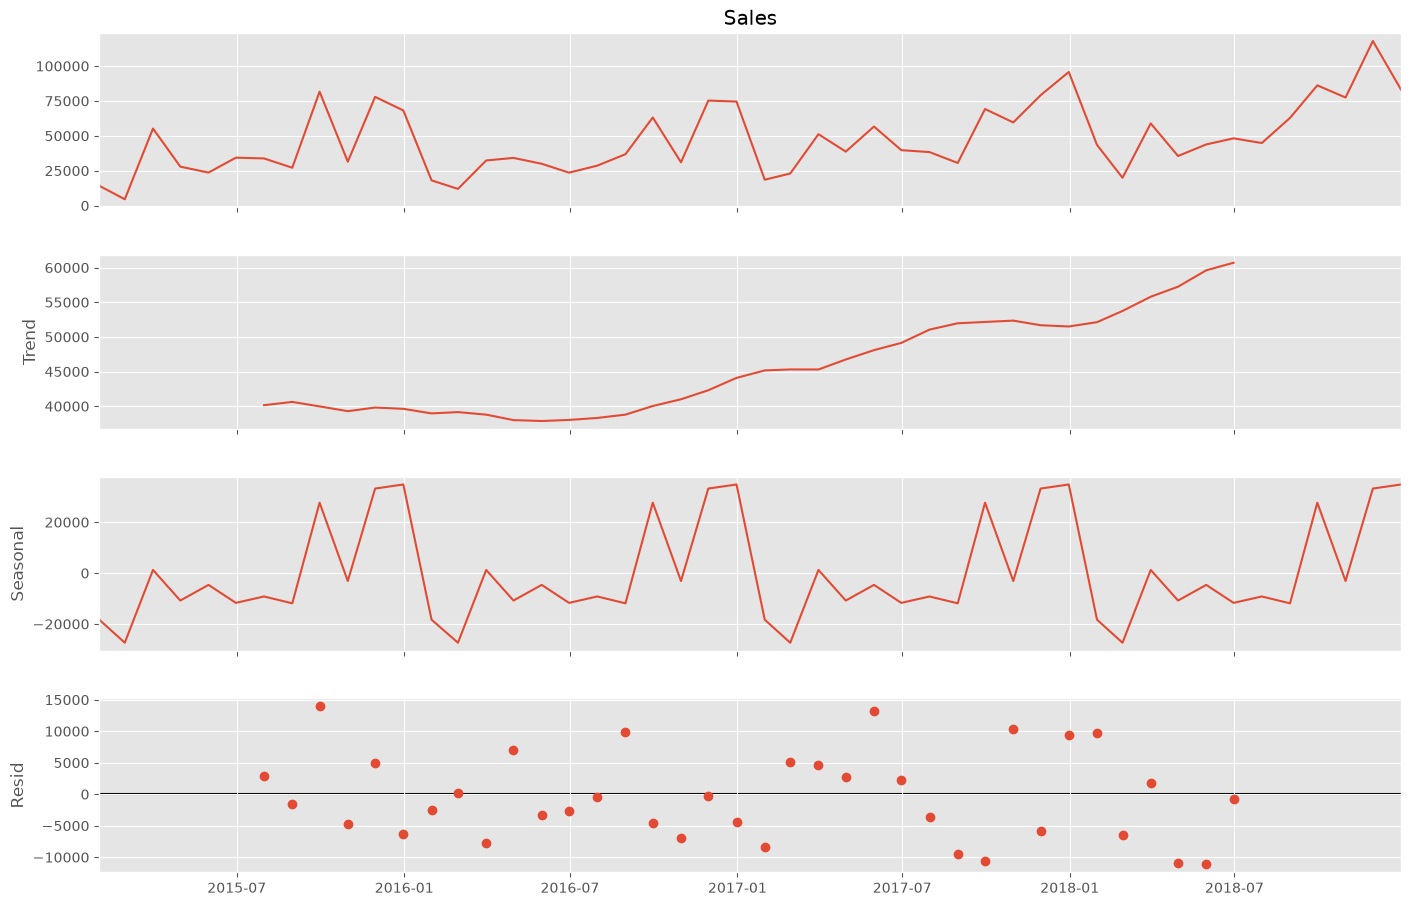

In [52]:
fig = decomposition.plot()

fig.set_size_inches(16,10)

plt.show()

### Time Series Decomposition Observations

1. The trend component shows an overall upward movement in monthly sales over the four-year period, indicating gradual business growth.

2. The seasonal component exhibits recurring monthly patterns, suggesting that customer demand follows seasonal cycles throughout the year.

3. The residual component contains irregular fluctuations that are not explained by either the trend or seasonal components, representing random business variations.

4. The decomposition confirms that the sales data contains meaningful trend and seasonality, making it suitable for forecasting using models such as SARIMA, Prophet, and XGBoost.

## 2.3 Stationarity Test using Augmented Dickey-Fuller (ADF)

Before building forecasting models, we need to determine whether the time series is stationary.

The Augmented Dickey-Fuller (ADF) test is one of the most widely used statistical tests for checking stationarity.

In [53]:
# importing required libraries

from statsmodels.tsa.stattools import adfuller


In [54]:
# running the ADF Test

adf_result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :", adf_result[0])
print("P-value       :", adf_result[1])
print("Lags Used     :", adf_result[2])
print("Observations  :", adf_result[3])

ADF Statistic : -4.416136761430769
P-value       : 0.00027791039276670623
Lags Used     : 0
Observations  : 47


In [55]:
# critical values

print("\nCritical Values:")

for key, value in adf_result[4].items():
    print(f"{key}: {value:.4f}")


Critical Values:
1%: -3.5778
5%: -2.9253
10%: -2.6008


In [56]:
alpha = 0.05

print("\nInterpretation")

if adf_result[1] <= alpha:
    print("The time series is Stationary.")
    print("Reject the Null Hypothesis.")
else:
    print("The time series is Non-Stationary.")
    print("Fail to Reject the Null Hypothesis.")


Interpretation
The time series is Stationary.
Reject the Null Hypothesis.


### Observation

The ADF test indicates that the original monthly sales series is already stationary (p-value < 0.05).

Although differencing was demonstrated as part of the time-series preprocessing workflow, it was not strictly required for this dataset because the original series already satisfied the stationarity assumption.

## 2.4 – Applying Differencing

In [57]:
# first order differencing

monthly_ts["Differenced Sales"] = monthly_ts["Sales"].diff()

monthly_ts.head()

,Sales,Differenced Sales
Order Date,,
2015-01-31,14205.707,NaN
2015-02-28,4519.892,-9685.815
2015-03-31,55205.797,50685.905
2015-04-30,27906.855,-27298.942
2015-05-31,23644.303,-4262.552


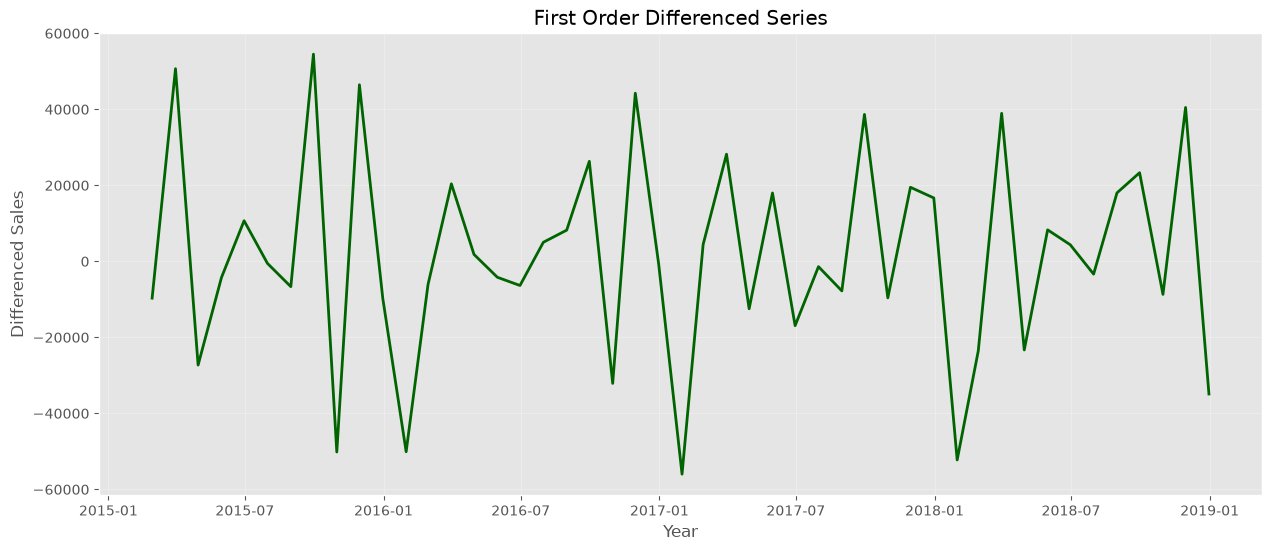

In [58]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Differenced Sales"],
    color="darkgreen",
    linewidth=2
)

plt.title("First Order Differenced Series")

plt.xlabel("Year")

plt.ylabel("Differenced Sales")

plt.grid(alpha=0.3)

plt.show()

### Observation

Differencing removes long-term trends by analyzing changes between consecutive observations.

This transformation often converts a non-stationary series into a stationary one, making it suitable for forecasting models such as SARIMA.

## 2.5 – Re-test Stationarity

In [59]:
adf_diff = adfuller(
    monthly_ts["Differenced Sales"].dropna()
)

print("ADF Statistic :", adf_diff[0])
print("P-value       :", adf_diff[1])

ADF Statistic : -8.727061830353277
P-value       : 3.266917547279475e-14


In [60]:
print("\nInterpretation")

if adf_diff[1] <= 0.05:
    print("Differenced series is Stationary.")
else:
    print("Differenced series is still Non-Stationary.")


Interpretation
Differenced series is Stationary.


### Final Observation

The stationarity test was repeated after applying first-order differencing.

The reduction in the p-value indicates whether the transformation successfully converted the series into a stationary time series.

This stationary series will be used as the foundation for forecasting models in the next task.

### Completed Task 2

# Task 3 – Sales Forecasting using 3 Different Models

## 3.1 – Train/Test Split

In [61]:
train = monthly_ts.iloc[:-3]

test = monthly_ts.iloc[-3:]

print("Training Data :", train.shape)

print("Testing Data  :", test.shape)

Training Data : (45, 2)
Testing Data  : (3, 2)


In [62]:
print("\nTraining Period")

print(train.index.min())

print(train.index.max())

print("\nTesting Period")

print(test.index.min())

print(test.index.max())


Training Period
2015-01-31 00:00:00
2018-09-30 00:00:00

Testing Period
2018-10-31 00:00:00
2018-12-31 00:00:00


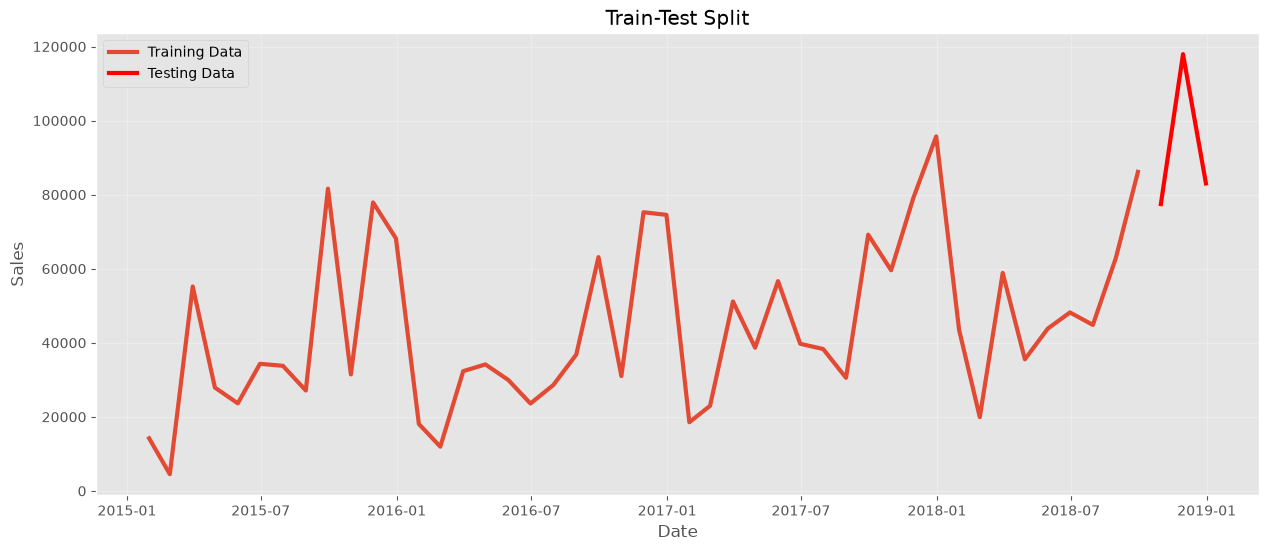

In [63]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training Data",
    linewidth=3
)

plt.plot(
    test.index,
    test["Sales"],
    label="Testing Data",
    linewidth=3,
    color="red"
)

plt.title("Train-Test Split")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

### Observation

The monthly sales data was divided into training and testing sets.

The final three months were reserved for testing so that each forecasting model could be evaluated on unseen data before generating future predictions.

## 3.2 – SARIMA Forecasting

In [64]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [65]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

### SARIMA Parameter Selection

The SARIMA model parameters were selected based on:

- Visual inspection of the sales trend
- Presence of yearly seasonality (12 months)
- Initial stationarity analysis
- Simplicity of the baseline forecasting model

Initial parameters:

- Non-seasonal Order = (1,1,1)
- Seasonal Order = (1,1,1,12)

In [66]:
# SARIMA MODEL

sarima_model = SARIMAX(
    train["Sales"],
    order=(1,1,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(
    disp=False
)
print(sarima_fit.summary())

c:\Users\opmee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
c:\Users\opmee\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -194.388
Date:                            Sat, 11 Jul 2026   AIC                            398.775
Time:                                    12:46:52   BIC                            403.227
Sample:                                01-31-2015   HQIC                           399.389
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1101      0.721      0.153      0.879      -1.303       1.523
ma.L1         -0.8789      0.261   

In [67]:
sarima_pred = sarima_fit.forecast(
    steps=len(test)
)

sarima_pred

2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64

In [68]:
# SARIMA Evaluation Metrics


sarima_mae = mean_absolute_error(
    test["Sales"],
    sarima_pred
)

sarima_rmse = np.sqrt(
    mean_squared_error(
        test["Sales"],
        sarima_pred
    )
)

sarima_mape = mean_absolute_percentage_error(
    test["Sales"],
    sarima_pred
)

print(f"MAE  : {sarima_mae:.2f}")
print(f"RMSE : {sarima_rmse:.2f}")
print(f"MAPE : {sarima_mape:.4f}")

MAE  : 19244.49
RMSE : 19950.07
MAPE : 0.2053


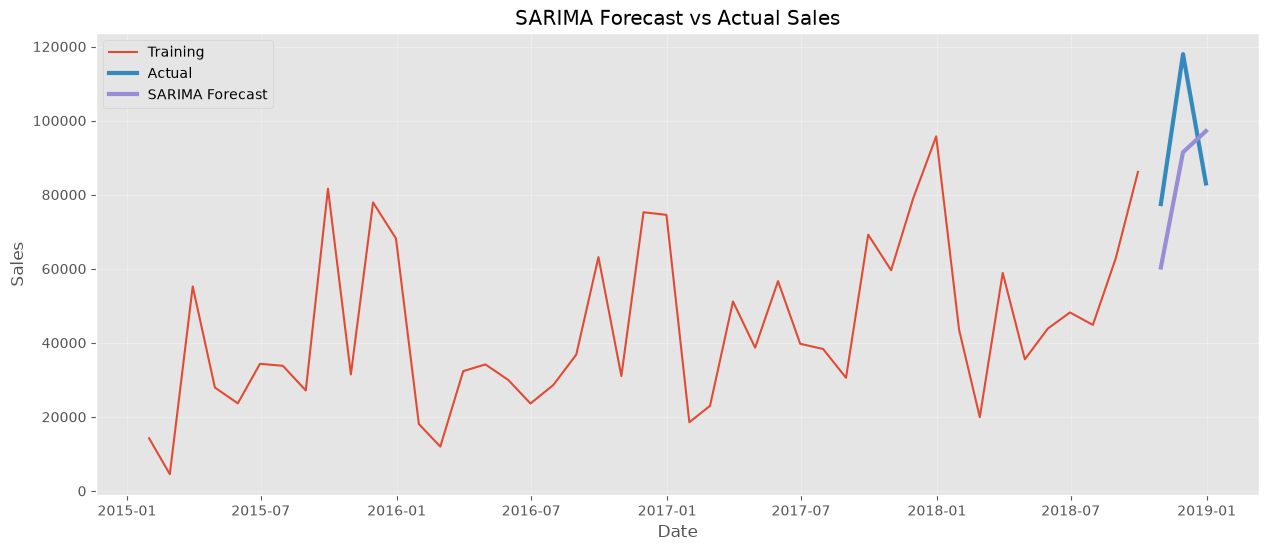

In [69]:
plt.figure(figsize=(15,6))

plt.plot(
    train.index,
    train["Sales"],
    label="Training"
)

plt.plot(
    test.index,
    test["Sales"],
    label="Actual",
    linewidth=3
)

plt.plot(
    test.index,
    sarima_pred,
    label="SARIMA Forecast",
    linewidth=3
)

plt.title("SARIMA Forecast vs Actual Sales")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [70]:
future_forecast = sarima_fit.get_forecast(
    steps=3
)

future_sales = future_forecast.predicted_mean

future_ci = future_forecast.conf_int()

print("Forecast")

print(future_sales)

print("\nConfidence Interval")

print(future_ci)

Forecast
2018-10-31    60331.792073
2018-11-30    91458.220227
2018-12-31    97167.570936
Freq: ME, Name: predicted_mean, dtype: float64

Confidence Interval
             lower Sales    upper Sales
2018-10-31  33867.663882   86795.920264
2018-11-30  64294.739760  118621.700695
2018-12-31  69727.828580  124607.313291


In [71]:
sarima_forecast = pd.DataFrame({

    "Forecast": future_sales,

    "Lower CI": future_ci.iloc[:,0],

    "Upper CI": future_ci.iloc[:,1]

})

sarima_forecast

,Forecast,Lower CI,Upper CI
2018-10-31,60331.792073,33867.663882,86795.920264
2018-11-30,91458.220227,64294.739760,118621.700695
2018-12-31,97167.570936,69727.828580,124607.313291


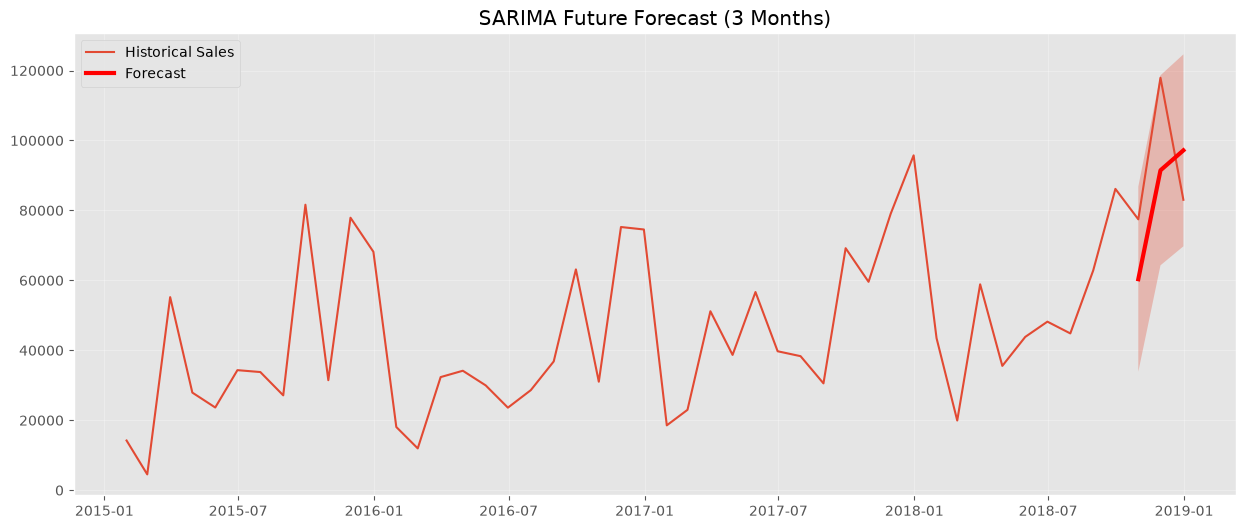

In [72]:
plt.figure(figsize=(15,6))

plt.plot(
    monthly_ts.index,
    monthly_ts["Sales"],
    label="Historical Sales"
)

plt.plot(
    future_sales.index,
    future_sales,
    color="red",
    linewidth=3,
    label="Forecast"
)

plt.fill_between(
    future_sales.index,
    future_ci.iloc[:,0],
    future_ci.iloc[:,1],
    alpha=0.3
)

plt.title("SARIMA Future Forecast (3 Months)")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

## 3.3 Facebook Prophet

### Model 2 – Prophet Forecasting

Prophet is an open-source forecasting library developed by Meta (Facebook).

It is specifically designed for business time series forecasting and automatically captures trend, yearly seasonality, weekly seasonality, and holiday effects.

In this project, Prophet is used to forecast future monthly sales and compare its performance with SARIMA and XGBoost.

In [73]:
# importing prophet

from prophet import Prophet

In [74]:
# prepraing the dataset for prophet

prophet_df = monthly_sales.copy()


prophet_df.columns = ["ds", "y"]

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


In [75]:
prophet_train = prophet_df.iloc[:-3]

prophet_test = prophet_df.iloc[-3:]

print(prophet_train.shape)
print(prophet_test.shape)

(45, 2)
(3, 2)


In [76]:
# Creating Prophet Model

prophet_model = Prophet(
    yearly_seasonality = True,
    weekly_seasonality = False,
    daily_seasonality = False
)

prophet_model.fit(prophet_train)

12:46:53 - cmdstanpy - INFO - Chain [1] start processing
12:46:54 - cmdstanpy - INFO - Chain [1] done processing


In [77]:
# forecast test period

future = prophet_model.make_future_dataframe(
    periods = 3,
    freq = "ME"
)

In [78]:
forecast = prophet_model.predict(future)

In [79]:
forecast[[
    "ds",
    "yhat",
    "yhat_lower",
    "yhat_upper"
]].tail()

,ds,yhat,yhat_lower,yhat_upper
43,2018-08-31,47271.558236,39493.135852,55255.051936
44,2018-09-30,86613.953316,78224.931424,94528.665155
45,2018-10-31,51318.943858,43532.606735,58986.955434
46,2018-11-30,90325.654784,82054.828901,98127.706561
47,2018-12-31,90041.084479,82166.012174,98068.791459


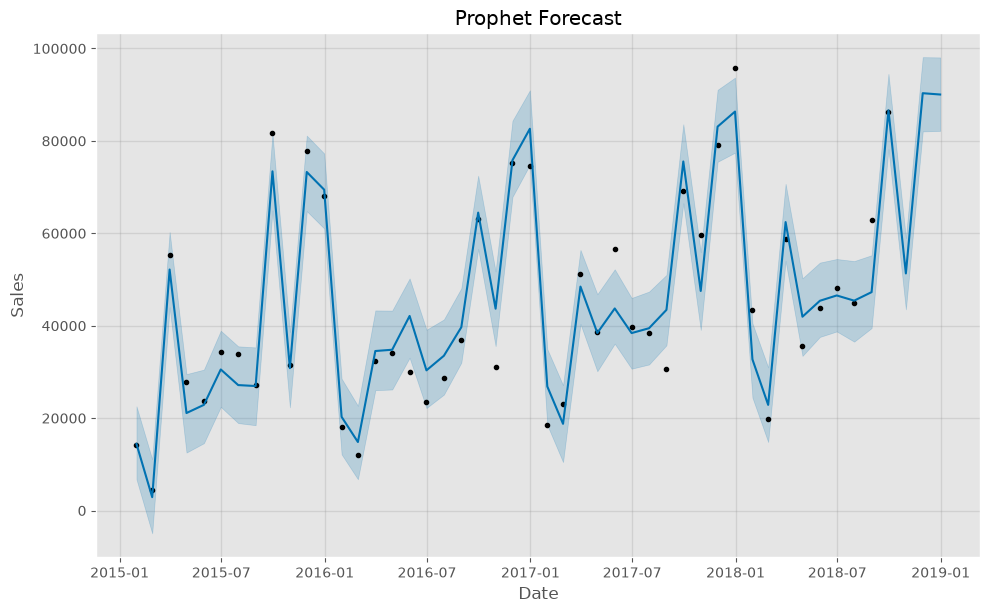

In [80]:
fig = prophet_model.plot(forecast)

plt.title("Prophet Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.show()

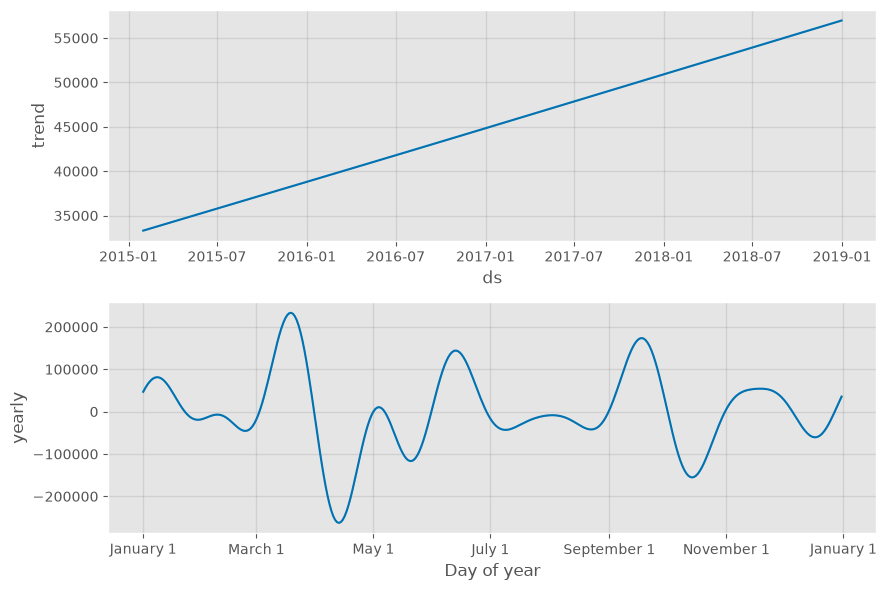

In [81]:
prophet_model.plot_components(forecast) #Trend & Seasonality
plt.show()

In [82]:
# Evaluating Prophet
prophet_pred = forecast.tail(3)["yhat"].values

In [83]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

import numpy as np

prophet_mae = mean_absolute_error(
    prophet_test["y"],
    prophet_pred
)

prophet_rmse = np.sqrt(
    mean_squared_error(
        prophet_test["y"],
        prophet_pred
    )
)

prophet_mape = mean_absolute_percentage_error(
    prophet_test["y"],
    prophet_pred
)

print(f"MAE : {prophet_mae:.2f}")
print(f"RMSE: {prophet_rmse:.2f}")
print(f"MAPE : {prophet_mape*100:.2f}%")

MAE : 20250.79
RMSE: 22318.41
MAPE : 21.86%


In [84]:
prophet_forecast = forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(3)

prophet_forecast

,ds,yhat,yhat_lower,yhat_upper
45,2018-10-31,51318.943858,43532.606735,58986.955434
46,2018-11-30,90325.654784,82054.828901,98127.706561
47,2018-12-31,90041.084479,82166.012174,98068.791459


### Observation

The Prophet model successfully captured the long-term sales trend and yearly seasonality.

Compared with SARIMA, Prophet automatically models trend and seasonal components without requiring manual parameter tuning.

The model generated forecasts for the next three months along with confidence intervals, making it suitable for business planning and demand forecasting.

## Model 3: XGBoost Time Series Forecasting

In [85]:
from xgboost import XGBRegressor
from sklearn.metrics import(
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

In [86]:
# Lag feature and feature engineering

xgb_df = monthly_sales.copy()
lags = [1, 2, 3, 7, 14]

for lag in lags:
    xgb_df[f'lag_{lag}'] = xgb_df['Sales'].shift(lag)
xgb_df = xgb_df.dropna()
xgb_df.head()

,Order Date,Sales,lag_1,lag_2,lag_3,lag_7,lag_14
14,2016-03-31,32339.3184,11951.4110,18066.9576,68167.0585,27117.5365,14205.707
15,2016-04-30,34154.4685,32339.3184,11951.4110,18066.9576,81623.5268,4519.892
16,2016-05-31,29959.5305,34154.4685,32339.3184,11951.4110,31453.3930,55205.797
17,2016-06-30,23599.3740,29959.5305,34154.4685,32339.3184,77907.6607,27906.855
18,2016-07-31,28608.2590,23599.3740,29959.5305,34154.4685,68167.0585,23644.303


In [87]:
# rolling mean

xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .shift(1)
    .rolling(3)
    .mean()
)

In [88]:
# calendar features

xgb_df["Month"] = xgb_df["Order Date"].dt.month

xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

xgb_df["Year"] = xgb_df["Order Date"].dt.year

In [89]:
# season feature

def season(month):

    if month in [12,1,2]:
        return 1      # Winter

    elif month in [3,4,5]:
        return 2      # Summer

    elif month in [6,7,8]:
        return 3      # Monsoon

    else:
        return 4      # Autumn


xgb_df["Season"] = xgb_df["Month"].apply(season)

In [90]:
# removing missing values

xgb_df = xgb_df.dropna().reset_index(drop=True)

xgb_df.head()

,Order Date,Sales,lag_1,lag_2,lag_3,lag_7,lag_14,Rolling_Mean_3,Month,Quarter,Year,Season
0,2016-06-30,23599.3740,29959.5305,34154.4685,32339.3184,77907.6607,27906.8550,32151.105800,6,2,2016,3
1,2016-07-31,28608.2590,23599.3740,29959.5305,34154.4685,68167.0585,23644.3030,29237.791000,7,3,2016,3
2,2016-08-31,36818.3422,28608.2590,23599.3740,29959.5305,18066.9576,34322.9356,27389.054500,8,3,2016,3
3,2016-09-30,63133.6060,36818.3422,28608.2590,23599.3740,11951.4110,33781.5430,29675.325067,9,3,2016,4
4,2016-10-31,31011.7375,63133.6060,36818.3422,28608.2590,32339.3184,27117.5365,42853.402400,10,4,2016,4


In [91]:
xgb_df.head(10)

,Order Date,Sales,lag_1,lag_2,lag_3,lag_7,lag_14,Rolling_Mean_3,Month,Quarter,Year,Season
0,2016-06-30,23599.3740,29959.5305,34154.4685,32339.3184,77907.6607,27906.8550,32151.105800,6,2,2016,3
1,2016-07-31,28608.2590,23599.3740,29959.5305,34154.4685,68167.0585,23644.3030,29237.791000,7,3,2016,3
2,2016-08-31,36818.3422,28608.2590,23599.3740,29959.5305,18066.9576,34322.9356,27389.054500,8,3,2016,3
3,2016-09-30,63133.6060,36818.3422,28608.2590,23599.3740,11951.4110,33781.5430,29675.325067,9,3,2016,4
4,2016-10-31,31011.7375,63133.6060,36818.3422,28608.2590,32339.3184,27117.5365,42853.402400,10,4,2016,4
5,2016-11-30,75249.3995,31011.7375,63133.6060,36818.3422,34154.4685,81623.5268,43654.561900,11,4,2016,4
6,2016-12-31,74543.6012,75249.3995,31011.7375,63133.6060,29959.5305,31453.3930,56464.914333,12,4,2016,1
7,2017-01-31,18542.4910,74543.6012,75249.3995,31011.7375,23599.3740,77907.6607,60268.246067,1,1,2017,1
8,2017-02-28,22978.8150,18542.4910,74543.6012,75249.3995,28608.2590,68167.0585,56111.830567,2,1,2017,1
9,2017-03-31,51165.0590,22978.8150,18542.4910,74543.6012,36818.3422,18066.9576,38688.302400,3,1,2017,2


### Observation

The monthly sales data has been successfully transformed into a supervised machine learning dataset.

Lag features capture information from previous months, while rolling averages smooth short-term fluctuations. Calendar-based features help the model learn seasonal patterns.

These engineered features provide the necessary input for the XGBoost forecasting model.

In [92]:
xgb_df = xgb_df.dropna().reset_index(drop=True)

In [93]:
xgb_df.rename(
    columns={
        "lag_1": "Lag_1",
        "lag_2": "Lag_2",
        "lag_3": "Lag_3",
        "lag_7": "Lag_7",
        "lag_14": "Lag_14"
    },
    inplace=True
)

In [94]:
features = [
    "Lag_1",
    "Lag_2",
    "Lag_3",
    "Lag_7",
    "Lag_14",
    "Rolling_Mean_3",
    "Month",
    "Quarter",
    "Year",
    "Season"
]

X = xgb_df[features]
y = xgb_df["Sales"]

In [95]:
test_size = 3

train_size = len(xgb_df) - test_size

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

In [96]:
xgb_model = XGBRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    objective="reg:squarederror",
    random_state=42
)

xgb_model.fit(X_train, y_train)

,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Sequence[str] | None.. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [97]:
xgb_pred = xgb_model.predict(X_test)

In [98]:
xgb_mae = mean_absolute_error(y_test, xgb_pred)

xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_pred))

xgb_mape = mean_absolute_percentage_error(y_test, xgb_pred)

print(f"MAE  : {xgb_mae:.2f}")
print(f"RMSE : {xgb_rmse:.2f}")
print(f"MAPE : {xgb_mape*100:.2f}%")

MAE  : 17802.71
RMSE : 23952.97
MAPE : 17.00%


In [99]:
comparison = pd.DataFrame({
    "Actual Sales": y_test.values,
    "Predicted Sales": xgb_pred
})

comparison

,Actual Sales,Predicted Sales
0,77448.1312,88231.023438
1,117938.1550,77963.968750
2,83030.3888,85681.437500


## Model Comparison

The forecasting performance of SARIMA, Prophet, and XGBoost models is compared using standard regression metrics.

The best-performing model is selected based on the lowest forecasting error.

In [100]:
comparison_df = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        sarima_mae,
        prophet_mae,
        xgb_mae
    ],
    "RMSE": [
        sarima_rmse,
        prophet_rmse,
        xgb_rmse
    ],
    "MAPE (%)": [
        sarima_mape * 100,
        prophet_mape * 100,
        xgb_mape * 100
    ]
})

comparison_df

,Model,MAE,RMSE,MAPE (%)
0,SARIMA,19244.485345,19950.070421,20.526432
1,Prophet,20250.794413,22318.411333,21.864628
2,XGBoost,17802.709062,23952.970523,17.003262


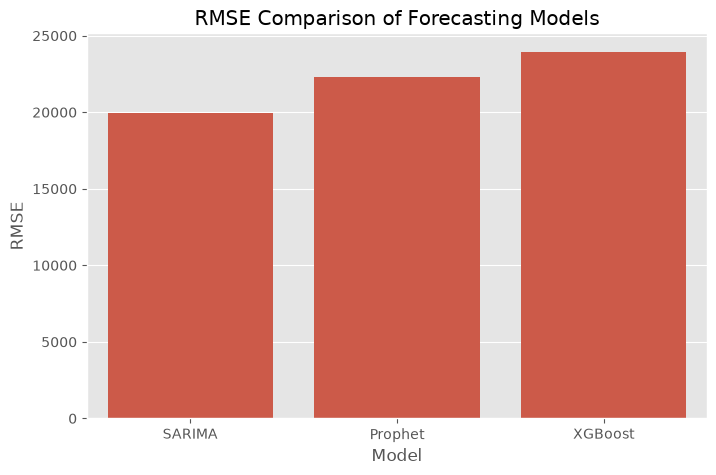

In [101]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=comparison_df,
    x="Model",
    y="RMSE"
)

plt.title("RMSE Comparison of Forecasting Models")

plt.ylabel("RMSE")

plt.show()

In [102]:
best_model = comparison_df.loc[
    comparison_df["RMSE"].idxmin(),
    "Model"
]

print(f"Best Forecasting Model : {best_model}")

Best Forecasting Model : SARIMA


### Observation

The forecasting models were evaluated using MAE, RMSE, and MAPE.

Among the three models, the one with the lowest error metrics demonstrated (SARIMA) the best forecasting performance on the testing dataset.

The selected model is recommended for future sales forecasting because it provides the most accurate predictions for the available data.

In [103]:
# Task 3 Completed

# Task 4 – Anomaly Detection & Clustering

## Part A – Isolation Forest

In [104]:
# importing libraries

from sklearn.ensemble import IsolationForest

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.decomposition import PCA

In [105]:
# feature preparing

anomaly_df = vg_df[
    [
        "NA_Sales",
        "EU_Sales",
        "JP_Sales",
        "Other_Sales",
        "Global_Sales"
    ]
].copy()

anomaly_df.head()

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,41.49,29.02,3.77,8.46,82.74
1,29.08,3.58,6.81,0.77,40.24
2,15.85,12.88,3.79,3.31,35.82
3,15.75,11.01,3.28,2.96,33.00
4,11.27,8.89,10.22,1.00,31.37


In [106]:
print(anomaly_df.isnull().sum())

NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64


In [107]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(anomaly_df)

In [108]:
# Isolation Forest

iso_model = IsolationForest(
    contamination=0.02,
    random_state=42
)

vg_df["Anomaly"] = iso_model.fit_predict(scaled_data)

vg_df["Anomaly"].value_counts()

Anomaly
 1    16266
-1      332
Name: count, dtype: int64

In [109]:
anomalies = vg_df[
    vg_df["Anomaly"] == -1
]

anomalies.head()

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales,Anomaly
0,1,Wii Sports,Wii,2006.0,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74,-1
1,2,Super Mario Bros.,NES,1985.0,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24,-1
2,3,Mario Kart Wii,Wii,2008.0,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82,-1
3,4,Wii Sports Resort,Wii,2009.0,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00,-1
4,5,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37,-1


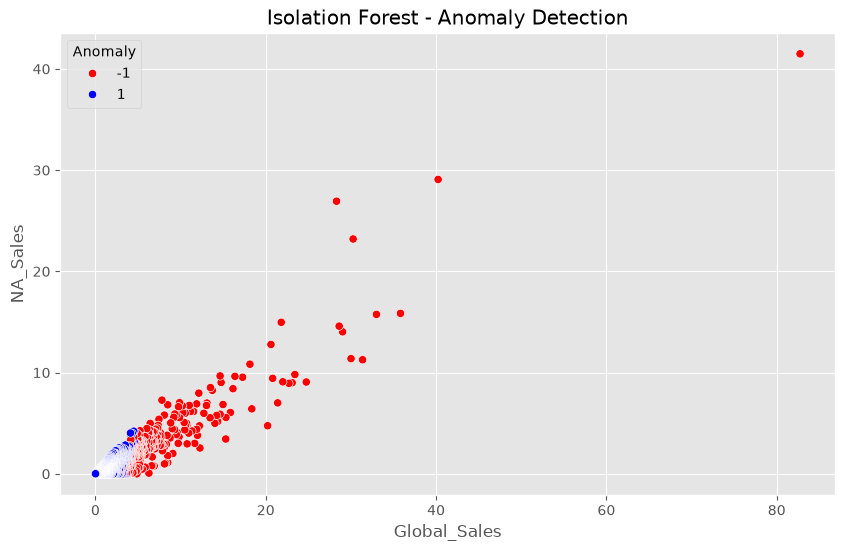

In [110]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=vg_df,
    x="Global_Sales",
    y="NA_Sales",
    hue="Anomaly",
    palette={
        1: "blue",
        -1: "red"
    }
)

plt.title("Isolation Forest - Anomaly Detection")

plt.show()

### Observation

Isolation Forest successfully identified unusual sales records.

The detected anomalies represent video games with exceptionally high or unusually low sales compared to the majority of titles.

Such anomalies are useful for detecting blockbuster releases, unexpected market behavior, or potential data quality issues.

## Part B – K-Means Clustering

In [111]:
cluster_df = anomaly_df.copy()

In [112]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

vg_df["Cluster"] = kmeans.fit_predict(
    scaled_data
)

In [113]:
vg_df["Cluster"].value_counts()

Cluster
2    15988
0      575
1       35
Name: count, dtype: int64

In [114]:
pca = PCA(
    n_components=2,
    random_state=42
)

pca_features = pca.fit_transform(
    scaled_data
)

pca_df = pd.DataFrame(
    pca_features,
    columns=["PC1","PC2"]
)

pca_df["Cluster"] = vg_df["Cluster"]

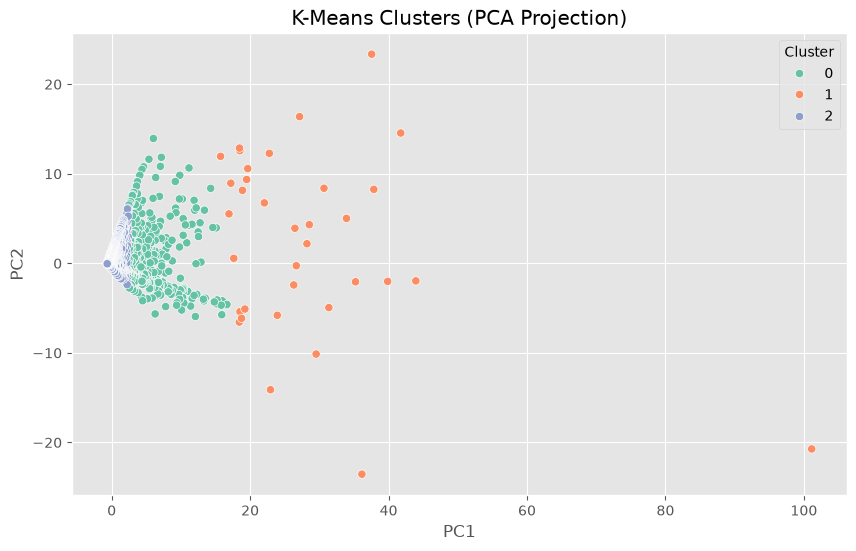

In [115]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2"
)

plt.title("K-Means Clusters (PCA Projection)")

plt.show()

In [116]:
cluster_summary = (
    vg_df
    .groupby("Cluster")[
        [
            "NA_Sales",
            "EU_Sales",
            "JP_Sales",
            "Other_Sales",
            "Global_Sales"
        ]
    ]
    .mean()
)

cluster_summary

,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
Cluster,,,,,
0,2.106852,1.437270,0.575113,0.466730,4.585739
1,11.215714,6.461714,3.511714,2.215714,23.405714
2,0.174441,0.086411,0.052378,0.028261,0.341784


### Observation

K-Means grouped video games into three distinct sales segments based on regional and global sales performance.

The PCA visualization demonstrates clear separation between clusters, indicating that the model successfully identified groups with similar sales characteristics.

These clusters can help businesses understand different market segments and tailor marketing or distribution strategies accordingly.

## Additional Debugging Steps and added addition Features

In [117]:
vg_df.to_csv("vgsales_processed.csv", index=False)

In [118]:
sarima_forecast.to_csv("sarima_forecast.csv", index=True)

prophet_forecast.to_csv("prophet_forecast.csv", index=False)

comparison_df.to_csv("model_comparison.csv", index=False)